# High F-score vs random baskets — global minimum variance

The companion to `equal_weighted.ipynb`. Selection is unchanged; only the construction
layer differs, so any gap between the two notebooks is attributable to weighting alone.

Both arms are re-weighted by a long-only **global minimum variance** portfolio. Running
GMV on the null as well as on the strategy is the point: variance optimisation helps
*any* basket, and only a null under the same construction can separate that generic
low-volatility effect from stock selection.

In [15]:
import sqlite3
from contextlib import closing

import portfolio_util as port_util
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)

K, N_SIM = 25, 2000
SEEDS = {"f_rand": 20260810, "random": 20260811}   # keyed by ARM, not by weighting

DB = "../fscore.db"
COV_WINDOW_M = 36      # months of history behind each formation-date covariance
MIN_COV_OBS = 12       # fewer observations than this -> fall back to median variance
SHRINK_DELTA = 0.30    # weight of the diagonal when shrinking the correlation matrix

## 1. Universe

`build_universe` screens **nothing** — whatever is passed in is the pool that *both* the
strategy and the null draw from, so the filter below defines the entire experiment. A row
is investable at formation only if it clears every gate at once:

| gate | meaning |
|---|---|
| `tradeable` | passed the 30-day pre-formation liquidity screen |
| `f_score` | all nine signals were scoreable |
| `bm` | book-to-market exists (implies shares and a December price) |
| `fwd_return_1y` | entry and exit prices found **and** the holding year has finished |

The last gate is what stops the panel at formation year 2025: a portfolio formed
30/6/2026 does not know its 30/6/2027 exit yet.

In [16]:
panel = pd.read_csv("../data/preprocessing_pipeline_results/final_panel.csv").set_index(["symbol", "period"])

investable = (panel["tradeable"].eq(True)
              & panel["f_score"].notna()
              & panel["bm"].notna()
              & panel["fwd_return_1y"].notna())
investable.value_counts()

False    12453
True      8780
Name: count, dtype: int64

In [17]:
universe = port_util.build_universe(panel[investable])
universe

Universe(T=14, years=2012-2025, rows=8,780, symbols=1,362)

In [18]:
# Names available each year — the pool both arms draw from.
universe.sizes().to_frame().T

formation_year,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
n_names,329,416,430,473,515,553,542,586,690,878,844,857,859,808


## 2. Covariance — the extra input GMV needs

Equal weight needs nothing beyond the panel. GMV needs a risk model, and that risk model
must be **point-in-time**: for a portfolio formed 30/6/`y` the estimator may see only the
`COV_WINDOW_M` months ending June `y`, never a month of the holding period it is about to
weight.

Monthly total returns come from adjusted closes, so dividends and splits are already in.
The estimator then shrinks the pairwise correlation matrix toward the diagonal, falls back
to the cross-sectional median variance for names with too little history, and floors the
eigenvalues. That last step matters mechanically: pairwise-complete covariance need not be
positive semi-definite, and flooring the year matrix makes every 30x30 submatrix a path
can select PSD too, so the solver cannot blow up.

In [19]:
MONTHLY_SQL = """
select symbol, substr(date, 1, 7) as month, price_close * unit / adj_ratio as close_adj
from (
    select symbol, date, price_close, unit, adj_ratio,
           row_number() over (partition by symbol, substr(date, 1, 7)
                              order by date desc) as rn
    from fireant_prices
    where unit = 1000 and price_close > 0 and adj_ratio > 0
) where rn = 1
"""
with closing(sqlite3.connect(f"file:{DB}?mode=ro", uri=True)) as conn:
    month_end = pd.read_sql(MONTHLY_SQL, conn)

monthly_returns = (month_end.pivot(index="month", columns="symbol", values="close_adj")
                   .sort_index().pct_change(fill_method=None))
print(f"{monthly_returns.shape[0]} months x {monthly_returns.shape[1]} symbols"
      f"   |   {monthly_returns.index[0]} -> {monthly_returns.index[-1]}")

212 months x 1824 symbols   |   2009-01 -> 2026-08


In [20]:
covariance = port_util.build_cov(monthly_returns, universe, window_m=COV_WINDOW_M,
                                min_obs=MIN_COV_OBS, shrink=SHRINK_DELTA)
print(f"{len(covariance)} matrices, one per formation year")
pd.Series({int(y): covariance[y].shape[0] for y in universe.years},
          name="n_names").to_frame().T

14 matrices, one per formation year


,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
n_names,329,416,430,473,515,553,542,586,690,878,844,857,859,808


## 2. The two arms

Both arms run through the same `build_portfolio` call and differ in exactly one flag:

| arm | ranking key | |
|---|---|---|
| `random` | uniform noise | the no-skill null |
| `f_rand` | `f_score` + uniform noise | the strategy |

`f_rand` is **also** 2,000 paths, not one. `f_score` is an integer 0-9, so a cut at K = 30
almost always lands inside a block of tied names — in 2023, all thirty slots come from the
34 names scoring 9. Breaking those ties at random and repeating makes the strategy a
distribution too, differing from the null in one respect only: the eligible pool.

Seeds are keyed by **arm**, not by weighting. Reusing them across notebooks makes the EW
and GMV portfolios share their selections exactly, which is what isolates construction
from selection.

In [21]:
null_gmv = port_util.build_portfolio(universe, "random", k=K, weighting="gmv",
                                     cov=covariance, n_sim=N_SIM, seed=SEEDS["random"])
null_gmv

Portfolio(arm='random', weighting='gmv', k=25, n_paths=2000)

In [22]:
# The null distribution itself: one row per Monte-Carlo path.
null_gmv.draws().describe().loc[["mean", "std", "min", "50%", "max"]]

,cagr,mean_ann,vol_ann,sharpe,mdd,wturn,effn,maxw
mean,0.165836,0.183203,0.213776,0.882791,-0.097817,0.978880,7.886600,0.255777
std,0.036789,0.039988,0.053257,0.200809,0.082209,0.013536,0.565456,0.023933
min,0.060708,0.074021,0.097275,0.314579,-0.562135,0.908320,5.860731,0.189024
50%,0.165805,0.181991,0.207714,0.862715,-0.080719,0.981624,7.900261,0.254245
max,0.297056,0.337453,0.535909,2.075050,0.000000,1.000000,9.983978,0.344890


In [23]:
f_gmv = port_util.build_portfolio(universe, "f_rand", k=K, weighting="gmv",
                                  cov=covariance, n_sim=N_SIM, seed=SEEDS["f_rand"])
f_gmv

Portfolio(arm='f_rand', weighting='gmv', k=25, n_paths=2000)

## 3. Results

`metrics_table` collapses each path's 14 annual returns into one CAGR, one Sharpe, one
drawdown, then reads the strategy's mean against the null's 2,000-path distribution.
`z` is the standardised distance; `p_mc` is the Monte-Carlo p-value with the conservative
+1 correction.

`paired_test` asks a different question: differencing year by year removes the common
market effect, so it tests whether the *edge* is stable rather than whether the market
rose. With T = 14 non-overlapping annual observations it has little power — expect it to
be the weaker of the two, and report both.

Unlike the equal-weight notebook, `effn` and `maxw` are live here — weights vary, so
concentration is something the null can be tested against.

In [24]:
port_util.metrics_table(f_gmv, null_gmv).round(4)

,value,value_sd,null_mean,null_sd,null_p05,null_p95,z,p_mc,win_rate
metric,,,,,,,,,
cagr,0.2281,0.0203,0.1658,0.0368,0.1063,0.2269,1.6933,0.0485,0.9320
mean_ann,0.2403,0.0230,0.1832,0.0400,0.1189,0.2516,1.4267,0.0760,0.8949
vol_ann,0.1836,0.0375,0.2138,0.0533,0.1405,0.3107,-0.5668,0.2944,0.3226
sharpe,1.3448,0.2047,0.8828,0.2008,0.5929,1.2440,2.3006,0.0250,0.9474
mdd,-0.0194,0.0306,-0.0978,0.0822,-0.2552,0.0000,0.9533,0.1334,0.8423
wturn,0.9022,0.0173,0.9789,0.0135,0.9534,0.9962,-5.6640,0.0010,0.0013
effn,7.3071,0.3672,7.8866,0.5655,6.9577,8.8299,-1.0249,0.3148,0.1952
maxw,0.2724,0.0186,0.2558,0.0239,0.2179,0.2970,0.6955,0.4558,0.7159


In [25]:
pd.DataFrame([port_util.paired_test(f_gmv, null_gmv, "f_rand - random (GMV)")]).set_index("test").round(4)

,mean,sd,T,t,p_two_sided,p_one_sided,wins
test,,,,,,,
f_rand - random (GMV),0.0571,0.1101,14,1.9394,0.0745,0.0372,12


## 4. Charts

`plot_null` draws the null histogram with the strategy marked; the pale band around the
red line is the strategy's **own** 5-95% spread, which matters because a random tiebreak
makes it a distribution too. A point outside the null means much less when its own spread
straddles the null.

`plot_equity` compounds the mean path against the null's band. The x axis is labelled by
**exit** year: equity at position `i` is what a portfolio formed in year `i` is worth once
its holding period closes.

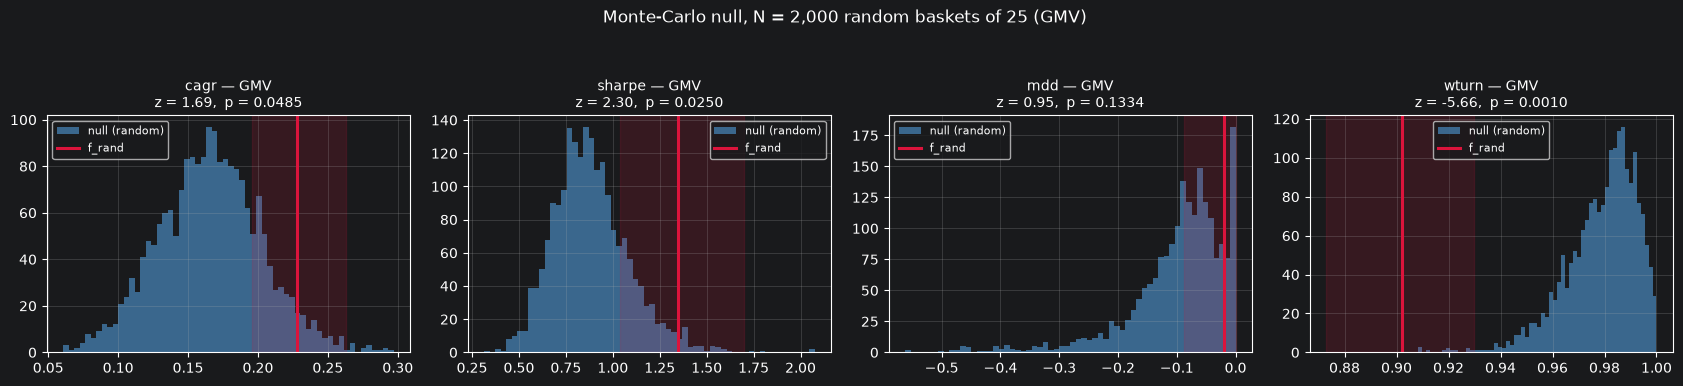

In [26]:
fig, axes = plt.subplots(1, 4, figsize=(17, 3.6))
for ax, metric in zip(axes, ["cagr", "sharpe", "mdd", "wturn"]):
    port_util.plot_null(f_gmv, null_gmv, metric, ax=ax)
fig.suptitle(f"Monte-Carlo null, N = {N_SIM:,} random baskets of {K} (GMV)", y=1.06)
fig.tight_layout()
plt.show()

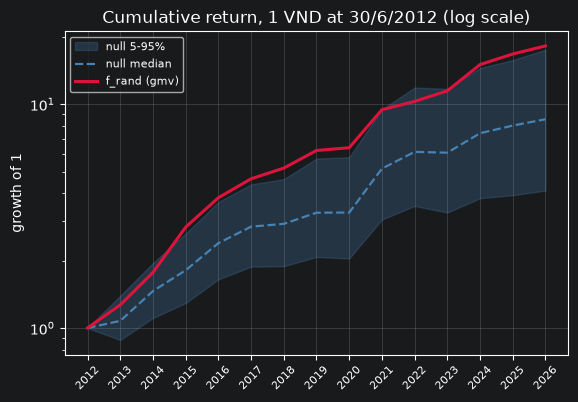

In [27]:
port_util.plot_equity(f_gmv, null_gmv)
plt.show()

## 5. What GMV does to concentration

A "30-name portfolio" under GMV is nothing of the sort. The long-only solver drives most
weights to zero, and `effn = 1 / sum(w^2)` counts how many names the portfolio behaves as
if it held. Read `max_weight` alongside it: a single name approaching half the book is a
concentration risk that equal weight cannot produce and that the headline metrics do not
surface.

In [28]:
pd.DataFrame({
    "effective_n": {int(y): (1.0 / (f_gmv.W[y] ** 2).sum(axis=1)).mean()
                    for y in universe.years},
    "max_weight": {int(y): f_gmv.W[y].max(axis=1).mean() for y in universe.years},
    "n_nonzero": {int(y): (f_gmv.W[y] > 1e-9).sum(axis=1).mean() for y in universe.years},
}).rename_axis("formation_year").round(3)

,effective_n,max_weight,n_nonzero
formation_year,,,
2012,6.749,0.239,11.684
2013,8.146,0.196,13.810
2014,6.664,0.235,12.204
2015,7.906,0.234,15.304
2016,9.214,0.228,17.493
2017,11.244,0.168,19.333
2018,6.985,0.306,17.173
2019,9.450,0.213,19.613
2020,7.591,0.266,15.192
